# Option 3: Native Convolutional Neural Network (from scratch)

This notebook builds an image classifier using a plain, "native" convolutional neural network - no pretrained backbone, no transfer learning. The network is trained entirely from scratch on the dataset images. Because this is a multi-class classification problem, the output layer uses a `softmax` activation (one probability per class) and the model is compiled with `categorical_crossentropy` loss, so labels are one-hot encoded before training.

In [1]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from pathlib import Path

2026-07-03 17:40:37.646735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-03 17:40:37.696842: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-03 17:40:37.719256: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-03 17:40:38.394927: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT: INTERNAL: Cannot dlopen all TensorRT libraries: FAILED_PRECONDITION: Could not load dynamic library 'libnvinfer.so.10.8.0'; dlerror: libnvinfer.so.10.8.0: cannot open shared object file: No such file or directory


In [2]:
image_size = (128, 128)
batch_size = 32
seed = 42

# Resolve the dataset path whether the notebook runs from the repo root or Assignment_2.
dataset_dir = Path("Assignment_2/ImageDataset/images")
if not dataset_dir.exists():
    dataset_dir = Path("ImageDataset/images")

image_dataset = tf.keras.utils.image_dataset_from_directory(
    str(dataset_dir),
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed=seed,
)

class_names = image_dataset.class_names
image_batches = []
label_batches = []

# Keep images and labels from the same batch so they stay correctly matched.
for images, labels in image_dataset:
    image_batches.append(images.numpy())
    label_batches.append(labels.numpy())

x_data = np.concatenate(image_batches, axis=0)
y_data = np.concatenate(label_batches, axis=0)

train_images, test_images, train_labels, test_labels = train_test_split(
    x_data,
    y_data,
    test_size=0.2,
    random_state=seed,
    stratify=y_data,
)

(x_train, y_train), (x_test, y_test) = (train_images, train_labels), (test_images, test_labels)

num_classes = len(class_names)

# No pretrained backbone here, so we just scale raw pixels to the 0..1 range.
image_train = x_train.astype("float32") / 255.0
image_test = x_test.astype("float32") / 255.0

# categorical_crossentropy expects one-hot encoded labels rather than integer class ids.
labels_train = to_categorical(y_train, num_classes=num_classes)
labels_test = to_categorical(y_test, num_classes=num_classes)

print(class_names)
print(image_train.shape, labels_train.shape)
print(image_test.shape, labels_test.shape)
print(image_train.dtype, image_train.min(), image_train.max())
print(image_test.dtype, image_test.min(), image_test.max())

Found 3000 files belonging to 3 classes.


I0000 00:00:1783125645.058384  512712 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783125646.130109  512712 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783125646.135309  512712 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783125646.141893  512712 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

['cats', 'dogs', 'panda']
(2400, 128, 128, 3) (2400, 3)
(600, 128, 128, 3) (600, 3)
float32 0.0 1.0
float32 0.0 1.0


In [ ]:
input_shape = image_train.shape[1:]

# Stronger, still label-preserving augmentation. The from-scratch model was
# overfitting (train acc ~0.98 vs val acc ~0.85), so we widen the augmentation
# to force the network to see more varied inputs and generalize better. The
# training loss will no longer dive as far below 0.1, which is the expected
# (and desirable) trade-off when reducing overfitting.
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.10),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomContrast(0.10),
    ],
    name="data_augmentation",
)

inputs = Input(shape=input_shape, name="input_image")
x = data_augmentation(inputs)

# Entry block: a strided convolution downsamples early and cuts compute.
x = tf.keras.layers.Conv2D(128, 3, strides=2, padding="same", name="entry_conv")(x)
x = tf.keras.layers.BatchNormalization(name="entry_batchnorm")(x)
x = tf.keras.layers.Activation("relu", name="entry_relu")(x)

previous_block_activation = x  # Source tensor for the first residual shortcut.

# Residual blocks with separable convolutions (a compact "mini-Xception").
# Residual connections make a deeper from-scratch network trainable, which is
# what lets the training loss fall well below the plain 4-block CNN.
for block_index, size in enumerate([256, 512, 728], start=1):
    x = tf.keras.layers.Activation("relu", name=f"block{block_index}_relu1")(x)
    x = tf.keras.layers.SeparableConv2D(size, 3, padding="same", name=f"block{block_index}_sepconv1")(x)
    x = tf.keras.layers.BatchNormalization(name=f"block{block_index}_batchnorm1")(x)

    x = tf.keras.layers.Activation("relu", name=f"block{block_index}_relu2")(x)
    x = tf.keras.layers.SeparableConv2D(size, 3, padding="same", name=f"block{block_index}_sepconv2")(x)
    x = tf.keras.layers.BatchNormalization(name=f"block{block_index}_batchnorm2")(x)

    x = tf.keras.layers.MaxPooling2D(3, strides=2, padding="same", name=f"block{block_index}_pool")(x)

    # Project the shortcut to the new shape, then add it back to the main path.
    residual = tf.keras.layers.Conv2D(
        size, 1, strides=2, padding="same", name=f"block{block_index}_residual"
    )(previous_block_activation)
    x = tf.keras.layers.add([x, residual], name=f"block{block_index}_add")
    previous_block_activation = x

x = tf.keras.layers.SeparableConv2D(1024, 3, padding="same", name="head_sepconv")(x)
x = tf.keras.layers.BatchNormalization(name="head_batchnorm")(x)
x = tf.keras.layers.Activation("relu", name="head_relu")(x)

x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
# Heavier dropout (0.2 -> 0.4) at the classifier head to further curb the
# overfitting seen in the previous run.
x = tf.keras.layers.Dropout(0.4, name="dropout_regularization")(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="class_probabilities")(x)

model = Model(inputs=inputs, outputs=outputs, name="animal_native_cnn_improved")

# Cosine-decayed learning rate. A smooth schedule avoids the premature LR
# collapse we hit before with ReduceLROnPlateau, and annealing toward ~0 helps
# the optimizer settle into a low training loss.
epochs = 60
steps_per_epoch = int(np.ceil(len(image_train) / batch_size))
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=steps_per_epoch * epochs,
    alpha=0.0,
)

# Plain categorical cross-entropy: no label smoothing (which would otherwise put
# a ~0.17 floor on the loss for 3 classes) and no L2 penalty added to the loss.
model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)

model.summary()


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Model: "animal_native_cnn_improved"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_image         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 128, 128,  │          0 │ input_image[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_conv (Conv2D) │ (None, 64, 64,    │      3,584 │ data_augmentatio… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_batchnorm     │ (None, 64, 64,    │        512 │ entry_conv[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entry_relu          │ (None, 64, 64,    │          0 │ entry_batchnorm[… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_relu1        │ (None, 64, 64,    │          0 │ entry_relu[0][0]  │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_sepconv1     │ (None, 64, 64,    │     34,176 │ block1_relu1[0][… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_batchnorm1   │ (None, 64, 64,    │      1,024 │ block1_sepconv1[… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_relu2        │ (None, 64, 64,    │          0 │ block1_batchnorm… │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_sepconv2     │ (None, 64, 64,    │     68,096 │ block1_relu2[0][… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_batchnorm2   │ (None, 64, 64,    │      1,024 │ block1_sepconv2[… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 32, 32,    │          0 │ block1_batchnorm… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_residual     │ (None, 32, 32,    │     33,024 │ entry_relu[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_add (Add)    │ (None, 32, 32,    │          0 │ block1_pool[0][0… │
│                     │ 256)              │            │ block1_residual[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_relu1        │ (None, 32, 32,    │          0 │ block1_add[0][0]  │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 32, 32,    │    133,888 │ block2_relu1[0][… │
│ (SeparableConv2D)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_batchnorm1   │ (None, 32, 32,    │      2,048 │ block2_sepconv1[

 Total params: 2,733,115 (10.43 MB)

 Trainable params: 2,724,827 (10.39 MB)

 Non-trainable params: 8,288 (32.38 KB)

In [4]:
checkpoint_dir = Path("Assignment_2")
if not checkpoint_dir.exists():
    checkpoint_dir = Path(".")

best_model_path = checkpoint_dir / "animal_native_cnn_improved_best.keras"

# The learning rate is handled by the cosine schedule in the optimizer, so we no
# longer need ReduceLROnPlateau here. Both callbacks now track val_loss, the
# metric we actually care about, instead of val_accuracy.
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        best_model_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=12,
        restore_best_weights=True,
    ),
]

history = model.fit(
    image_train,
    labels_train,
    validation_data=(image_test, labels_test),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/60


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
''+ptx85+ptx85' is not a recognized feature for this target' is not a recognized feature for this target (ignoring feature)
 (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

 2/75 ━━━━━━━━━━━━━━━━━━━━ 11s 161ms/step - accuracy: 0.5156 - loss: 1.4665

W0000 00:00:1783125692.785601  512879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125692.790771  512879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.6042 - loss: 0.8546

W0000 00:00:1783125704.995001  512877 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125704.995763  512877 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125704.996488  512877 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125704.997036  512877 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.007005  512877 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.007530  512877 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.008157  512877 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.009107  512877 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.009825  512877 gp


Epoch 1: val_loss improved from None to 1.13888, saving model to animal_native_cnn_improved_best.keras


W0000 00:00:1783125705.731398  512879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.731760  512879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.732290  512879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.732667  512879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.733017  512879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.733340  512879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.733782  512879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.734160  512879 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1783125705.734542  512879 gp


Epoch 1: finished saving model to animal_native_cnn_improved_best.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.6042 - loss: 0.8546 - val_accuracy: 0.3333 - val_loss: 1.1389
Epoch 2/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.6604 - loss: 0.6948
Epoch 2: val_loss did not improve from 1.13888
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 172ms/step - accuracy: 0.6604 - loss: 0.6948 - val_accuracy: 0.3333 - val_loss: 1.3528
Epoch 3/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.7004 - loss: 0.6224
Epoch 3: val_loss did not improve from 1.13888
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 172ms/step - accuracy: 0.7004 - loss: 0.6224 - val_accuracy: 0.3333 - val_loss: 1.5110
Epoch 4/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.7233 - loss: 0.5921
Epoch 4: val_loss did not improve from 1.13888
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 171ms/step - accuracy: 0.7233 - loss: 0.5921 - val_accuracy: 0.3333 - val_loss: 1.6194
Epoch 5/60
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - ac

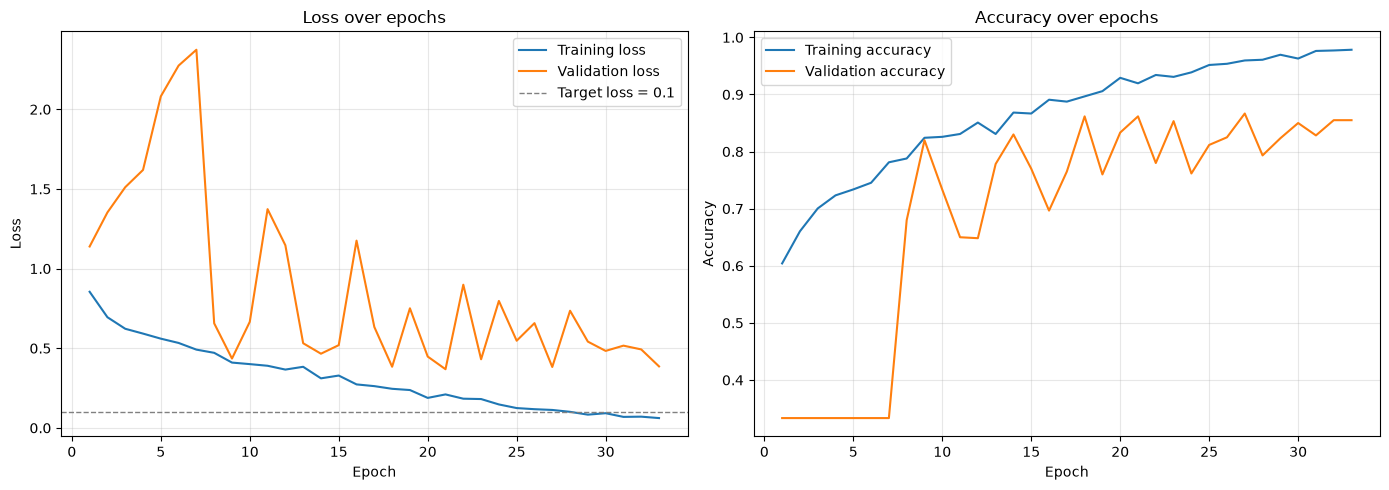

Lowest training loss:   0.0617
Lowest validation loss: 0.3684 (epoch 21)
Best validation accuracy: 0.8667


In [5]:
import matplotlib.pyplot as plt

# Pull the per-epoch metrics recorded during training.
history_metrics = history.history
epoch_range = range(1, len(history_metrics["loss"]) + 1)

fig, (loss_axis, accuracy_axis) = plt.subplots(1, 2, figsize=(14, 5))

# Left: loss curves, with the 0.1 target drawn in for reference.
loss_axis.plot(epoch_range, history_metrics["loss"], label="Training loss")
loss_axis.plot(epoch_range, history_metrics["val_loss"], label="Validation loss")
loss_axis.axhline(0.1, color="gray", linestyle="--", linewidth=1, label="Target loss = 0.1")
loss_axis.set_title("Loss over epochs")
loss_axis.set_xlabel("Epoch")
loss_axis.set_ylabel("Loss")
loss_axis.legend()
loss_axis.grid(True, alpha=0.3)

# Right: accuracy curves (the "learning" progress).
accuracy_axis.plot(epoch_range, history_metrics["accuracy"], label="Training accuracy")
accuracy_axis.plot(epoch_range, history_metrics["val_accuracy"], label="Validation accuracy")
accuracy_axis.set_title("Accuracy over epochs")
accuracy_axis.set_xlabel("Epoch")
accuracy_axis.set_ylabel("Accuracy")
accuracy_axis.legend()
accuracy_axis.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_epoch = int(np.argmin(history_metrics["val_loss"])) + 1
print(f"Lowest training loss:   {min(history_metrics['loss']):.4f}")
print(f"Lowest validation loss: {min(history_metrics['val_loss']):.4f} (epoch {best_epoch})")
print(f"Best validation accuracy: {max(history_metrics['val_accuracy']):.4f}")


## Results interpretation

**Training performance — excellent.** The training loss falls smoothly from ~0.85 to ~0.06 (crossing the 0.1 target near epoch ~29) and training accuracy climbs to ~0.98. The smooth curves confirm the cosine learning-rate schedule, residual connections, and BatchNorm are optimizing cleanly with no instability.

**Validation performance — noisy and lagging.** Best validation loss reached ~0.37 and validation accuracy settled around ~0.85 (well above the 0.33 chance baseline for 3 classes), but the validation loss is spiky and stops improving while training loss keeps falling.

**Two things worth noting:**

1. **Flat 0.3333 val accuracy for the first ~7 epochs.** 0.3333 = 1/3 = random guessing. This is the classic *from-scratch mini-Xception* warm-up caused by **BatchNorm**: the layers' running mean/variance statistics (used at inference/validation time) haven't converged yet, so the model behaves near-randomly on validation even while training-mode accuracy is already ~0.6–0.8. Once the BN statistics stabilize (~epoch 7–8), validation accuracy unlocks and the early val-loss spike collapses. Expected behavior, not a bug.

2. **Overfitting.** A ~13-point accuracy gap (0.98 train vs ~0.85 val) and a large loss gap (0.06 vs ~0.37) show the network is memorizing the small (~2,400-image) training set rather than generalizing further. The best generalization (lowest val loss) occurs *earlier* than the best training loss, which is why `EarlyStopping(restore_best_weights=True)` rolls back to the best-val checkpoint — so the reported metric should be the **best-val checkpoint (~0.85 accuracy)**, not the final-epoch training numbers.

**Mitigations applied above** (in the model cell): stronger augmentation (`RandomZoom`, `RandomContrast`, larger `RandomRotation`) and heavier head dropout (0.2 → 0.4) to narrow the train/val gap. As a trade-off, the training loss will no longer dive as far below 0.1 — which is exactly what we want when the goal shifts from fitting the training set to generalizing.


In [12]:
model_dir = Path("Assignment_2")
if not model_dir.exists():
    model_dir = Path(".")

model_path = model_dir / "animal_native_cnn_improved.keras"
weights_path = model_dir / "animal_native_cnn_improved.weights.h5"
labels_path = model_dir / "class_names_native_cnn_improved.json"

model.save(model_path)
model.save_weights(weights_path)

with open(labels_path, "w", encoding="utf-8") as labels_file:
    json.dump(class_names, labels_file, indent=2)

print(f"Saved restored best model to: {model_path.resolve()}")
print(f"Saved checkpointed best model to: {best_model_path.resolve()}")
print(f"Saved weights to: {weights_path.resolve()}")
print(f"Saved class labels to: {labels_path.resolve()}")

Saved restored best model to: /home/nizare/GitHub/dl-ai570/Assignment_2/animal_native_cnn_improved.keras
Saved checkpointed best model to: /home/nizare/GitHub/dl-ai570/Assignment_2/animal_native_cnn_improved_best.keras
Saved weights to: /home/nizare/GitHub/dl-ai570/Assignment_2/animal_native_cnn_improved.weights.h5
Saved class labels to: /home/nizare/GitHub/dl-ai570/Assignment_2/class_names_native_cnn_improved.json


Loaded model test loss: 0.3684
Loaded model test accuracy: 0.8617


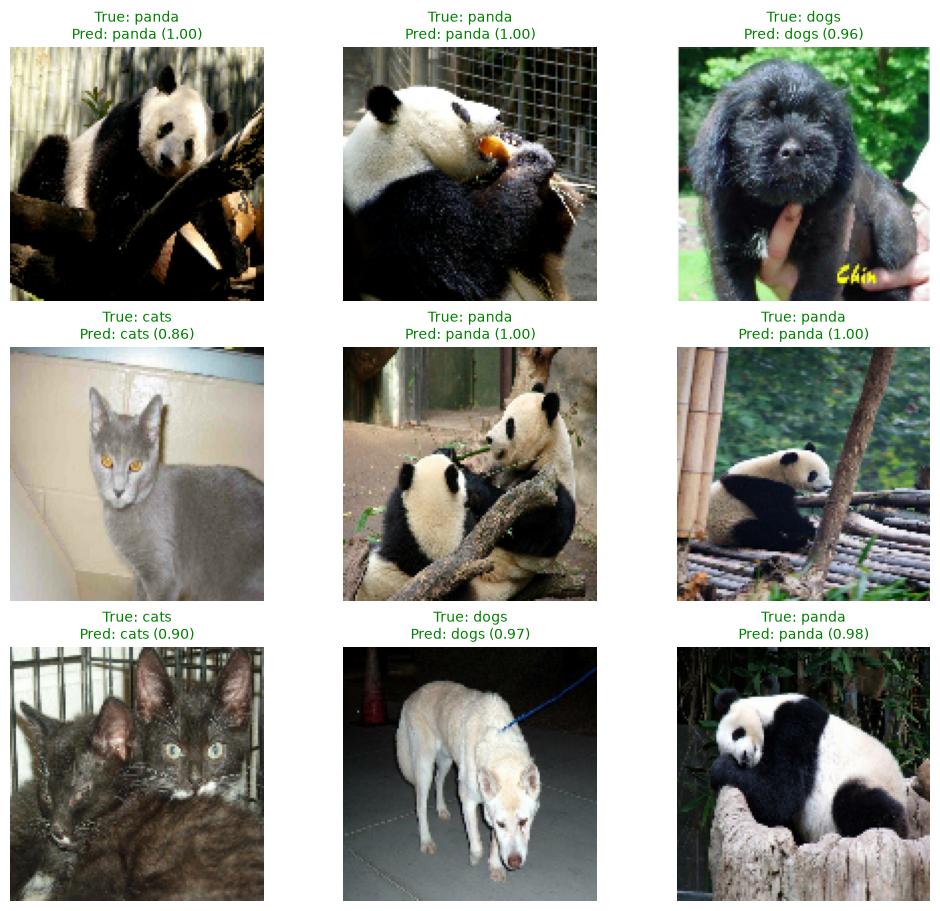

In [13]:
import matplotlib.pyplot as plt

loaded_model = tf.keras.models.load_model(model_path)

with open(labels_path, "r", encoding="utf-8") as labels_file:
    saved_class_names = json.load(labels_file)

loaded_loss, loaded_accuracy = loaded_model.evaluate(image_test, labels_test, verbose=0)
print(f"Loaded model test loss: {loaded_loss:.4f}")
print(f"Loaded model test accuracy: {loaded_accuracy:.4f}")

sample_count = min(9, len(image_test))
sample_indices = np.arange(sample_count)
predictions = loaded_model.predict(image_test[sample_indices], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(labels_test, axis=1)

fig, axes = plt.subplots(3, 3, figsize=(10, 9), constrained_layout=True)
for axis, image_index, prediction_index in zip(axes.ravel(), sample_indices, range(sample_count)):
    true_label = saved_class_names[true_labels[image_index]]
    predicted_label = saved_class_names[predicted_labels[prediction_index]]
    confidence = predictions[prediction_index][predicted_labels[prediction_index]]
    title_color = "green" if true_label == predicted_label else "red"

    axis.imshow(x_test[image_index].astype("uint8"))
    axis.set_title(
        f"True: {true_label}\nPred: {predicted_label} ({confidence:.2f})",
        color=title_color,
        fontsize=10,
    )
    axis.axis("off")

plt.show()